<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/02_construct_knowledge_graph_CustomPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Knowledge Graph Builder - Movies Knowledge Graph
## End-to-End `neo4j-graphrag` Pipeline

This notebook builds a movie knowledge graph from the **TMDB + IMDb Merged Movies Dataset** using the **fully-componentised `neo4j_graphrag` `Pipeline`**


### Architecture Components

The pipeline is composed of several custom and pre-built components:

*   **Data Loader:** Reads movie data from a CSV/Excel file.
*   **Text Splitter:** Transforms raw movie data into structured `TextChunk` objects.
*   **Chunk Embedder:** Generates vector embeddings for each text chunk.
*   **Schema Builder:** Defines the structure of the knowledge graph (Node Types, Relationship Types, Patterns).
*   **Entity & Relation Extractor:** Uses an LLM to identify entities and relationships based on the defined schema.
*   **KG Writer:** Persists the extracted graph data into a Neo4j database.
*   **Entity Resolver:** Deduplicates entities within the graph based on specified properties.
*   **Entity Embedder:** Creates embeddings for individual entities to enable entity-level vector search.

### Overall Flow
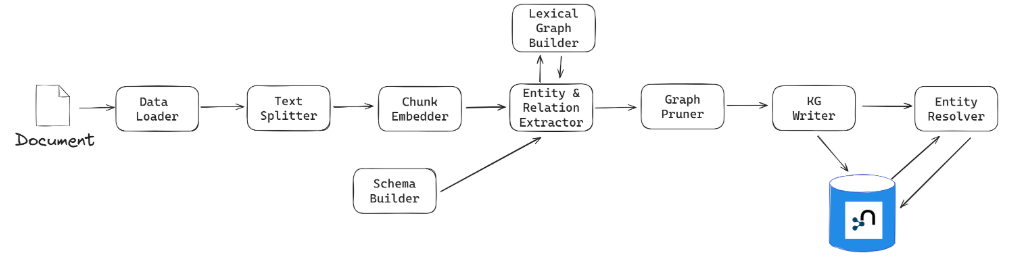

### What We Will Learn

By working through this notebook, you will learn about:

#### **1. Core `neo4j-graphrag` Pipeline**
*   How to set up and configure the `neo4j-graphrag` pipeline from end-to-end.

#### **2. Custom Component Development**
*   The process of creating custom data loading and text splitting components tailored to specific data sources.

#### **3. Knowledge Graph Schema Design**
*   Techniques for defining and enforcing a robust knowledge graph schema.

#### **4. LLM Integration for Information Extraction**
*   How to leverage Large Language Models (LLMs) for extracting structured information (entities and relationships) from unstructured text.

#### **5. Neo4j Database Management**
*   Methods for persisting and querying knowledge graphs in a Neo4j database.

#### **6. Graph Data Quality and Search Enhancement**
*   Strategies for entity resolution to merge duplicate nodes.
*   Adding embeddings to graph nodes for advanced semantic search capabilities.

### Tech Stack

*   **Python:** The primary programming language.
*   **Pandas:** For data manipulation and analysis.
*   **Neo4j:** Graph database for storing the knowledge graph.
*   **`neo4j-graphrag`:** Library for building and managing knowledge graphs.
*   **OpenAI API:** Used for Large Language Model (LLM) capabilities (entity extraction, embeddings).
*   **`dotenv`:** For managing environment variables and API keys.

In [1]:
!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

Cloning into 'Agentic_KAG_Workshop_DHS_2026'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (21/21), done.
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 299 (delta 66), reused 54 (delta 54), pack-reused 224 (from 2)
Receiving objects: 100% (299/299), 7.99 MiB | 19.95 MiB/s, done.
remote: Total 299 (delta 66), reused 54 (delta 54), pack-reused 224 (from 2)
Receiving objects: 100% (299/299), 7.99 MiB | 19.95 MiB/s, done.
Resolving deltas: 100% (158/158), done.
Resolving deltas: 100% (158/158), done.


Upload your '.env' file inside the 'Agentic_KAG_Workshop_DHS_2026' folder in the Files section

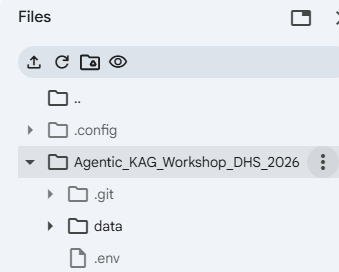

## Install Required Packages

In [2]:
# Run once per environment. Comment out after the first successful install.
%pip install --quiet -r /content/Agentic_KAG_Workshop_DHS_2026/requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.7/263.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.0/358.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.4/669.4 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.2 MB/s eta 0:00:00
   ━

## Credentials & Drivers

### Why are we doing this?
To build our Knowledge Graph, we need two things:
1. A place to store the graph (the **Neo4j Database**).
2. A brain to understand the text (the **OpenAI API**).

This cell loads your secret keys and connection details from a `.env` file so the code can talk to these services securely.

**Logic Flow:**
`Load .env File` -> `Read Database URI/Password` -> `Set OpenAI API Key` -> `Print Confirmation`

In [3]:
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    print("error reading env details")
    pass

# --- Neo4j Sandbox ---
NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE')

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

print('NEO4J_URI :', NEO4J_URI)
print('OPENAI key set:', bool(os.environ.get('OPENAI_API_KEY')))

NEO4J_URI : bolt://100.53.52.254
OPENAI key set: True


In [4]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
driver.verify_connectivity()
print('Connected to Neo4j ✔')

Connected to Neo4j ✔


## Initialize LLM & Embedder

### Understanding the 'Brain' and 'Translator'
*   **LLM (Large Language Model):** Think of this as the expert reader. We use `OpenAILLM` to read movie descriptions and decide which actors, directors, and genres exist.
*   **Embedder:** Think of this as a translator that turns human words into long lists of numbers (vectors). This allows the computer to 'calculate' how similar two movies are based on their meaning.

**Component Map:**
- `llm`: General extraction.
- `json_llm`: Special version that only speaks in data formats (JSON).
- `embedder`: Translates text to math.

In [14]:
from neo4j_graphrag.llm import OpenAILLM
from neo4j_graphrag.embeddings import OpenAIEmbeddings

# Main LLM used by LLMEntityRelationExtractor
llm = OpenAILLM(
    model_name='gpt-5-mini',
)

# Strict-JSON LLM (handy for schema extraction)
json_llm = OpenAILLM(
    model_name='gpt-5-mini',
    model_params={
        'response_format': {'type': 'json_object'},
    },
)

embedder = OpenAIEmbeddings(model='text-embedding-3-small')
print('LLM + embedder ready ✔')

LLM + embedder ready ✔


## Pipeline Structure

A Knowledge Graph (KG) construction pipeline requires a few components. Below are the 9 components.

1. **Data loader** – custom loader that reads the movies CSV
2. **Text splitter** – custom splitter that turns each movie row into a `TextChunk` with metadata (title, release_date, overview etc.).
3. **Chunk embedder** – embeds each chunk text with OpenAI embeddings.
4. **Schema builder** – manual `NodeType` / `RelationshipType` / `patterns` for the movie domain (Movie, Person, Genre, ProductionCompany, Country, Language, Keyword, CastMember). *Schema can be provided manually or extracted automatically using LLMs.* (both they styles are showcased in this notebook)
5. **Entity & relation extractor** – `LLMEntityRelationExtractor` grounded by the schema. Extract relevant entities and relations from the text.
6. **Graph pruner:** clean the graph based on schema, if provided.
7. **KG writer** – `Neo4jWriter` persists the extracted graph to Neo4J Sandbox. save the identified entities and relations.
8. **Entity resolver** – `SinglePropertyExactMatchResolver` merge similar entities into a single node.
9. **Entity embedder** (custom `Component`) – embeds the longest string property of each entity.


**Pipeline assembly** – `Pipeline().add_component(...)` + `pipe.connect(...)` + `await pipe.run(...)`.

**Validation Cypher queries** – sanity checks against the new movie schema (`CAST_IN`, `DIRECTED_BY`, `HAS_GENRE`, …).

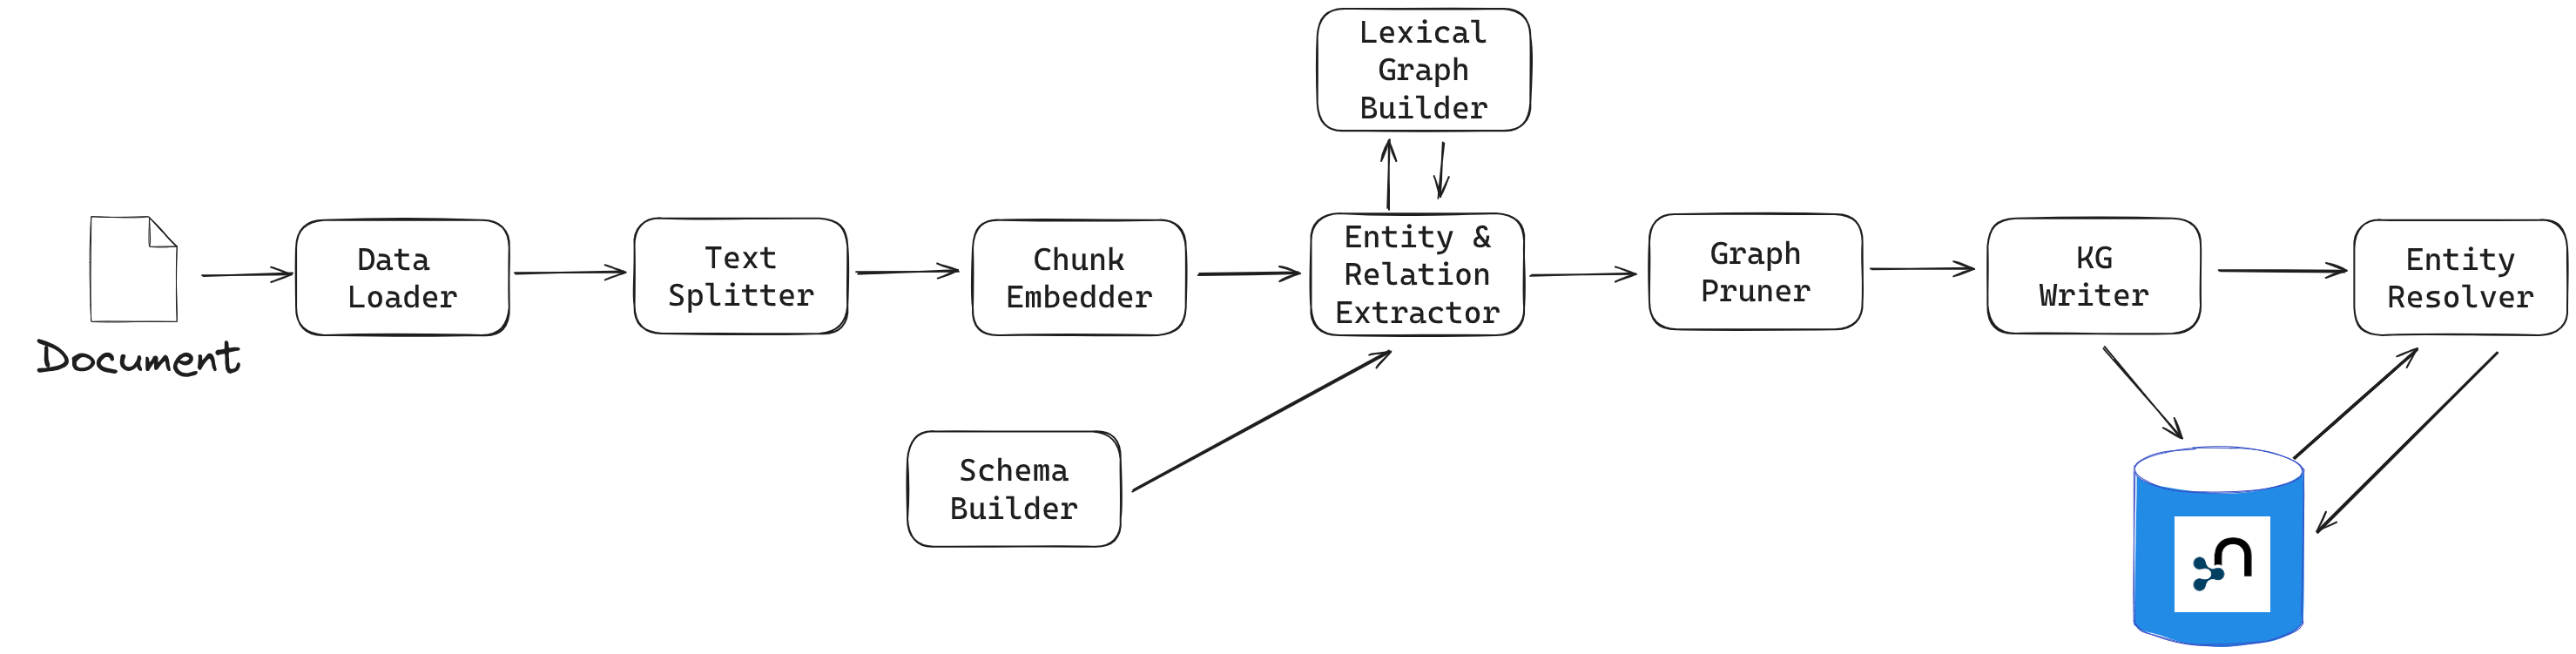

# Creating Components to Build Knowledge Graph
Components are asynchronous units of work that perform simple tasks, such as chunking documents or saving results to Neo4j. This package includes a few default components, but developers can create their own custom components as well.

## 1. Data Loader

### How we read the data
Before we can build a graph, we need raw data. Here we create a `MoviesDataLoader`. It opens our Excel file and converts the rows into a format the pipeline can process.

**The Process:**
`Excel File` -> `Pandas DataFrame` -> `Clean Dates/Empty Values` -> `List of Movie Dictionaries` -> `LoadedDocument` object.

In [ ]:
from pathlib import Path
import pandas as pd
import math
import os
import json
import ast
from neo4j_graphrag.experimental.components.data_loader import DataLoader
from neo4j_graphrag.experimental.components.types import LoadedDocument

excel_path = "/content/Agentic_KAG_Workshop_DHS_2026/data/TMDB_IMDB_Movies_Dataset_filtered.xlsx"

DATA_PATH = Path(excel_path)

class MoviesDataLoader(DataLoader):
    """Custom DataLoader that reads a movies CSV and returns a `Document` object.

    The `text` field of the returned `Document` object is a `repr()` of a list of per-movie dicts. The splitter (next step) will `ast.literal_eval` it.
    """

    def __init__(self, **kwargs):
        pass

    async def run(self, path: Path) -> LoadedDocument:
        df = pd.read_excel(path)
        print(f"Initial DataFrame shape: {df.shape}")

        df = df.reset_index(drop=True)

        # Convert 'release_date' column to datetime and then to the desired string format.
        # NA values will be replaced to None after string formatting.
        if 'release_date' in df.columns:
            df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
            df['release_date'] = df['release_date'].dt.strftime('%Y-%m-%d').replace({pd.NA: None})

        # Convert all NaN values to None before converting to dictionary, as ast.literal_eval cannot parse 'nan'
        df = df.where(pd.notna(df), None)

        # Convert the DataFrame to a list of dictionaries.
        # This handles NaN/NaT values by converting them to None by default for all columns.
        records = df.to_dict(orient='records')

        print(f'Loaded {len(records)} movie rows from {path.name} (no filtering applied).')

        return LoadedDocument(
            text=repr(records),
            document_info={'path': str(path)},
        )


# Execute
loader = MoviesDataLoader()
page_data = await loader.run(DATA_PATH)

Initial DataFrame shape: (4869, 26)
Loaded 4869 movie rows from TMDB_IMDB_Movies_Dataset_filtered.xlsx (no filtering applied).


## 2. Custom Text Splitter

### Creating 'Chunks' for the LLM
LLMs work best with small, focused pieces of text. This splitter takes our list of movies and turns each one into a `TextChunk`.

**Formatting Flow:**
`Raw Data` -> `Format (Label: Value)` -> `Add Metadata (Title, Date)` -> `Final TextChunk`

*Example:*
`Title: Eternals`
`Director: Chloé Zhao`
`Genres: Sci-Fi, Action`

In [ ]:
import ast
from neo4j_graphrag.experimental.components.text_splitters.base import TextSplitter
from neo4j_graphrag.experimental.components.types import TextChunks, TextChunk, LoadedDocument

def _row_to_movie_doc(rec: dict) -> str:
    """Build a multi-line, LLM-friendly text block for a single movie row."""
    lines = []

    # Define fields to display and their formatting
    display_fields = {
        'title': {'label': 'Title'},
        'release_date': {'label': 'Release date'},
        'runtime': {'label': 'Runtime (minutes)', 'formatter': lambda x: f"{x:.0f}"},
        'budget': {'label': 'Budget (USD)', 'formatter': lambda x: f"{x:,.0f}"},
        'revenue': {'label': 'Revenue (USD)', 'formatter': lambda x: f"{x:,.0f}"},
        'vote_average': {'label': 'Vote average', 'formatter': lambda x: f"{x:.1f}"},
        'genres': {'label': 'Genres'},
        'production_companies': {'label': 'Production companies'},
        'production_countries': {'label': 'Production countries'},
        'spoken_languages': {'label': 'Spoken languages'},
        'keywords': {'label': 'Keywords'},
        'directors': {'label': 'Director(s)'},
        'cast': {'label': 'Cast'},
        'tagline': {'label': 'Tagline'},
        'overview': {'label': 'Overview'},
    }

    for key, config in display_fields.items():
        value = rec.get(key)
        # Check for None, empty string, or empty collections (list, tuple, dict)
        if value is not None and value != '' and not (isinstance(value, (list, tuple, dict)) and not value):
            label = config['label']
            formatter = config.get('formatter')
            if formatter:
                # Apply formatter, handling potential errors if value is not numeric
                try:
                    formatted_value = formatter(value)
                except (TypeError, ValueError):
                    formatted_value = str(value) # Fallback to string conversion
            else:
                formatted_value = str(value)
            lines.append(f"{label}: {formatted_value}")

    return '\n'.join(lines)


class MoviesRowTextSplitter(TextSplitter):
    """Split the loader's Document into one TextChunk per movie row."""

    def __init__(self, dataset_name: str = 'TMDB+IMDb Movies'):
        self.dataset_name = dataset_name

    async def run(self, page_data: LoadedDocument) -> TextChunks:
        raw = page_data['text'] if isinstance(page_data, dict) else page_data.text
        records = ast.literal_eval(raw)

        chunks = []
        for i, rec in enumerate(records):
            chunks.append(TextChunk(
                index=i,
                text=_row_to_movie_doc(rec),
                metadata={
                    'title':        rec.get('title', ''),
                    'release_date': rec.get('release_date', ''),
                    'dataset':      self.dataset_name,
                },
            ))
        print(f'Built {len(chunks)} TextChunks (one per movie).')
        return TextChunks(chunks=chunks)


# Execute
splitter = MoviesRowTextSplitter()
text_chunks = await splitter.run(page_data)
print('*****First chunk preview:*******\n', text_chunks.chunks[0].text)

Built 4869 TextChunks (one per movie).
*****First chunk preview:*******
 Title: Eternals
Release date: 2021-11-03
Runtime (minutes): 156
Budget (USD): 200,000,000
Revenue (USD): 402,064,899
Vote average: 6.9
Genres: Science Fiction, Action, Adventure
Production companies: Marvel Studios
Production countries: Canada, United States of America
Spoken languages: Arabic, English, Hindi, Latin, Spanish
Keywords: superhero, supernatural, based on comic, alien, super power, aftercreditsstinger, marvel cinematic universe (mcu), sign languages, ancient, god-like
Director(s): Chloé Zhao
Cast: Gemma Chan, Richard Madden, Angelina Jolie, Salma Hayek Pinault, Kumail Nanjiani, Lia McHugh, Brian Tyree Henry, Lauren Ridloff, Barry Keoghan, Ma Dong-seok
Tagline: In the beginning...
Overview: The Eternals are a team of ancient aliens who have been living on Earth in secret for thousands of years. When an unexpected tragedy forces them out of the shadows, they are forced to reunite against mankind’s most 

In [ ]:
# display first chunk
text_chunks.chunks[0]

TextChunk(text='Title: Eternals\nRelease date: 2021-11-03\nRuntime (minutes): 156\nBudget (USD): 200,000,000\nRevenue (USD): 402,064,899\nVote average: 6.9\nGenres: Science Fiction, Action, Adventure\nProduction companies: Marvel Studios\nProduction countries: Canada, United States of America\nSpoken languages: Arabic, English, Hindi, Latin, Spanish\nKeywords: superhero, supernatural, based on comic, alien, super power, aftercreditsstinger, marvel cinematic universe (mcu), sign languages, ancient, god-like\nDirector(s): Chloé Zhao\nCast: Gemma Chan, Richard Madden, Angelina Jolie, Salma Hayek Pinault, Kumail Nanjiani, Lia McHugh, Brian Tyree Henry, Lauren Ridloff, Barry Keoghan, Ma Dong-seok\nTagline: In the beginning...\nOverview: The Eternals are a team of ancient aliens who have been living on Earth in secret for thousands of years. When an unexpected tragedy forces them out of the shadows, they are forced to reunite against mankind’s most ancient enemy, the Deviants.', index=0, met

## 3. Chunk Embedder

### Turning Words into Math
Computers don't understand text directly; they understand numbers. This step takes every piece of movie information and creates a 'vector' (a long list of coordinates). This allows us to perform mathematical searches for similar movies.

**Logic Flow:**
`Text Chunk` -> `OpenAI Embedding Model` -> `Vector Representation` -> `Stored in Metadata`

In [ ]:
from neo4j_graphrag.experimental.components.embedder import TextChunkEmbedder

text_chunk_embedder = TextChunkEmbedder(embedder=embedder)

## 4. Schema (Manual)

### Designing the Map
A Schema is the 'Rulebook' for our graph. It tells the AI:
*   **Nodes:** What types of things exist? (Movies, People, Genres).
*   **Relationships:** How are they connected? (A Person `DIRECTED` a Movie).
*   **Patterns:** Which connections are allowed?

**Visual Map:**
```
[Movie] --(DIRECTED_BY)--> [Person]
   |                          |
(HAS_GENRE)               (CAST_IN)
   v                          v
[Genre]                    [Movie]
```

In [ ]:
from neo4j_graphrag.experimental.components.schema import (
    SchemaBuilder,
    NodeType,
    RelationshipType,
    GraphSchema,
)

schema_builder = SchemaBuilder()

# -------- Node Types --------
node_types = [
    NodeType(
        label='Movie',
        description='A motion picture / film with metadata such as title, runtime, budget, revenue, release date and ratings.',
        properties=[
            {'name': 'title',         'type': 'STRING',  'description': 'Title of the movie.'},
            {'name': 'release_date',  'type': 'DATE',    'description': 'Theatrical release date (YYYY-MM-DD).'},
            {'name': 'runtime_minutes',       'type': 'INTEGER', 'description': 'Runtime in minutes.'},
            {'name': 'budget_usd',        'type': 'INTEGER', 'description': 'Production budget in USD.'},
            {'name': 'revenue_usd',       'type': 'INTEGER', 'description': 'Worldwide box-office revenue in USD.'},
            {'name': 'vote_average',  'type': 'FLOAT',   'description': 'Average user rating (typically 0–10).'},
            {'name': 'overview',      'type': 'STRING',  'description': 'Plot synopsis.'},
            {'name': 'tagline',       'type': 'STRING',  'description': 'Marketing tagline of the movie.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Person',
        description='A real person involved in a movie as director, writer, actor or other crew.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Full name of the person.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Genre',
        description='A film genre such as Action, Drama, Comedy, Horror, Science Fiction.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Canonical genre name.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='ProductionCompany',
        description='A company that produced or financed the movie.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Name of the production company.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Country',
        description='A country where the movie was produced.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Country name.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Language',
        description='A spoken language in the movie.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Language name (e.g. English, French).'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Keyword',
        description='A descriptive tag / theme attached to the movie (e.g. "time travel", "heist").',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Keyword text.'},
        ],
        additional_properties=True,
    ),
]

# -------- Relationship Types --------
relationship_types = [
    RelationshipType(label='HAS_GENRE',  description='Movie -[HAS_GENRE]-> Genre',                 properties=[], additional_properties=True),
    RelationshipType(label='PRODUCED_BY',description='Movie -[PRODUCED_BY]-> ProductionCompany',   properties=[], additional_properties=True),
    RelationshipType(label='PRODUCED_IN',description='Movie -[PRODUCED_IN]-> Country',             properties=[], additional_properties=True),
    RelationshipType(label='SPOKEN_IN',  description='Movie -[SPOKEN_IN]-> Language',              properties=[], additional_properties=True),
    RelationshipType(label='TAGGED_WITH',description='Movie -[TAGGED_WITH]-> Keyword',             properties=[], additional_properties=True),
    RelationshipType(label='DIRECTED_BY',description='Movie -[DIRECTED_BY]-> Person (director)',   properties=[], additional_properties=True),
    RelationshipType(label='WRITTEN_BY', description='Movie -[WRITTEN_BY]-> Person (writer)',      properties=[], additional_properties=True),
    RelationshipType(label='CAST_IN',    description='Person -[CAST_IN]-> Movie (actor appears in movie)', properties=[], additional_properties=True),
]

# -------- Patterns (allowed triplets) --------
patterns = [
    ('Movie',  'HAS_GENRE',   'Genre'),
    ('Movie',  'PRODUCED_BY', 'ProductionCompany'),
    ('Movie',  'PRODUCED_IN', 'Country'),
    ('Movie',  'SPOKEN_IN',   'Language'),
    ('Movie',  'TAGGED_WITH', 'Keyword'),
    ('Movie',  'DIRECTED_BY', 'Person'),
    ('Movie',  'WRITTEN_BY',  'Person'),
    ('Person', 'CAST_IN',     'Movie'),
]

# Build a manual schema using node, relationships and patterns
manual_schema = GraphSchema(
    node_types=node_types,
    relationship_types=relationship_types,
    patterns=patterns,
)

print('Schema ready:')
print('  node_types        :', [n.label for n in node_types])
print('  relationship_types:', [r.label for r in relationship_types])
print('  patterns          :', len(patterns))

Schema ready:
  node_types        : ['Movie', 'Person', 'Genre', 'ProductionCompany', 'Country', 'Language', 'Keyword']
  relationship_types: ['HAS_GENRE', 'PRODUCED_BY', 'PRODUCED_IN', 'SPOKEN_IN', 'TAGGED_WITH', 'DIRECTED_BY', 'WRITTEN_BY', 'CAST_IN']
  patterns          : 8


## 5. Schema (Extracted)

### Letting the AI Decide
Instead of manual rules, we can also ask the LLM to read a sample of our data and automatically suggest what the nodes and relationships should be. This is helpful for unexpected data patterns.

In [ ]:
from neo4j_graphrag.experimental.components.schema import SchemaFromTextExtractor
from neo4j_graphrag.llm import OpenAILLM

# Instantiate the automatic schema extractor component
schema_extractor = SchemaFromTextExtractor(
    llm=OpenAILLM(
        model_name="gpt-5-mini",
        model_params={
            #"max_tokens": 2000,
            "response_format": {"type": "json_object"},
        },
    )
)
# Slice only the first 1000 text chunks to avoid rate limit issues
full_text = "\n\n".join(chunk.text for chunk in text_chunks.chunks[:10])
# Extract the schema from the text
extracted_schema = await schema_extractor.run(text=full_text)

In [ ]:
print('--- Extracted Schema ---')

print('\nNode Types:')
for node_type in extracted_schema.node_types:
    print(f"  - Label: {node_type.label}")
    if node_type.properties:
        print('    Properties:')
        for prop in node_type.properties:
            print(f"      - Name: {prop.name}, Type: {prop.type}")

print('\nRelationship Types:')
for rel_type in extracted_schema.relationship_types:
    print(f"  - Label: {rel_type.label}")

print('\nPatterns:')
for pattern in extracted_schema.patterns:
    print(f"  - ({pattern.source})-[:{pattern.relationship}]->({pattern.target})")

--- Extracted Schema ---

Node Types:
  - Label: Movie
    Properties:
      - Name: title, Type: STRING
      - Name: release_date, Type: DATE
      - Name: runtime_minutes, Type: INTEGER
      - Name: budget_usd, Type: INTEGER
      - Name: revenue_usd, Type: INTEGER
      - Name: vote_average, Type: FLOAT
      - Name: tagline, Type: STRING
      - Name: overview, Type: STRING
  - Label: Person
    Properties:
      - Name: name, Type: STRING
  - Label: ProductionCompany
    Properties:
      - Name: name, Type: STRING
  - Label: Genre
    Properties:
      - Name: name, Type: STRING
  - Label: Country
    Properties:
      - Name: name, Type: STRING
  - Label: Language
    Properties:
      - Name: name, Type: STRING
  - Label: Keyword
    Properties:
      - Name: name, Type: STRING

Relationship Types:
  - Label: HAS_GENRE
  - Label: PRODUCED_BY
  - Label: PRODUCED_IN
  - Label: SPOKEN_LANGUAGE
  - Label: HAS_KEYWORD
  - Label: DIRECTED_BY
  - Label: HAS_CAST

Patterns:
  - (Movi

In [ ]:
import json
from IPython.display import display, Markdown

def schema_to_dict(schema):
    return {
        "nodes": [n.label for n in schema.node_types],
        "relationships": [r.label for r in schema.relationship_types],
        "patterns": [f"({p.source})-[:{p.relationship}]->({p.target})" for p in schema.patterns]
    }

# Prepare the prompt for the LLM
manual_dict = schema_to_dict(manual_schema)
extracted_dict = schema_to_dict(extracted_schema)

comparison_prompt = f"""
You are a Knowledge Graph expert. Compare the following two graph schemas and provide insights on:
1. Semantic differences (e.g., different names for the same concept).
2. Structural differences (missing nodes or relationships).
3. Recommendations for merging them for a production movie database.
Add tables wherever possible. Make it readable and crisp.

MANUAL SCHEMA:
{json.dumps(manual_dict, indent=2)}

EXTRACTED SCHEMA:
{json.dumps(extracted_dict, indent=2)}
"""

# Make the LLM call
response = llm.invoke(comparison_prompt)

# Display as Markdown
display(Markdown("### LLM Schema Analysis"))
display(Markdown(response.content))

### LLM Schema Analysis

Summary
- Both schemas cover core movie concepts (Movie, Person, Genre, Country, Language, Keyword, Company/ProductionCompany) but use different names and relation directions.  
- Key gaps: extracted schema missed writer relationships; manual schema uses different verbs and relationship directions for person roles.  
- I propose a small, consistent merged schema with standardized node/relationship names, required properties, useful relationship properties, and constraints/indexes for production use.

1) Semantic differences (synonyms / naming)
Table: node-name mapping
| Manual node       | Extracted node | Recommended unified node |
|-------------------|----------------|--------------------------|
| ProductionCompany | Company        | ProductionCompany (Company alias OK) |
| (all others) Movie, Person, Genre, Country, Language, Keyword | same | same |

Table: relationship-name mapping (manual → extracted → recommended)
| Manual rel.       | Extracted rel. | Semantic equivalence / note | Recommended unified rel. |
|-------------------|----------------|-----------------------------|--------------------------|
| HAS_GENRE         | HAS_GENRE      | same                        | :HAS_GENRE (Movie→Genre) |
| PRODUCED_BY       | PRODUCED_BY    | same target (company)       | :PRODUCED_BY (Movie→ProductionCompany) |
| PRODUCED_IN       | PRODUCED_IN    | same (country of production)| :PRODUCED_IN (Movie→Country) |
| SPOKEN_IN         | SPOKEN_IN      | same (language)             | :SPOKEN_IN (Movie→Language) |
| TAGGED_WITH       | HAS_KEYWORD    | keyword/tag synonym         | :HAS_KEYWORD (Movie→Keyword) |
| DIRECTED_BY       | DIRECTED       | same relation, different direction and naming | :DIRECTED (Person→Movie) |
| WRITTEN_BY        | (missing)      | writer relationship missing in extracted | :WROTE or :WROTE_BY (Person→Movie) |
| CAST_IN           | ACTED_IN       | same (actor cast), direction differs | :ACTED_IN (Person→Movie) |

Notes:
- Prefer verb-style relationships and person→movie direction for roles (Person)-[:ACTED_IN|:DIRECTED|:WROTE]->(Movie). This is more natural for queries like "find movies a person acted in".
- Use single canonical name for company node: ProductionCompany or Company. I recommend ProductionCompany for clarity, keep Company as alias.

2) Structural differences (missing nodes / relationships / directionality)
Table: structural gaps
| Issue | Manual schema | Extracted schema | Impact / action |
|-------|---------------|------------------|-----------------|
| Writer relationship | present (:WRITTEN_BY Movie→Person) | missing | Add :WROTE (Person→Movie) to extracted or keep both directions consistent |
| Person role direction | Movie→Person for DIRECTED_BY; Person→Movie for CAST_IN | Person→Movie for DIRECTED and ACTED_IN | Standardize person→movie direction for all person roles |
| Keyword relationship name | TAGGED_WITH | HAS_KEYWORD | Rename to :HAS_KEYWORD for consistency (prefer verb) |
| Company naming | ProductionCompany | Company | Unify to one node label (ProductionCompany) |
| Relationship properties | not specified | not specified | Add properties like character, billingOrder, job, creditOrder, role, startDate |
| Role granularity | separate relationships for director/writer/actor | extracted has director/actor only | Add :WROTE and optionally :PRODUCED (Person) for person-producers |
| Crew/credit entities | none | none | Consider adding Credit or Role node if you need historical credits with attributes |

3) Recommended merged schema (production-ready)
Nodes (labels) and key properties
| Label | key properties (indexed / unique) |
|-------|----------------------------------|
| Movie | movieId (PK), title, releaseDate, runtime, budget, revenue, rating |
| Person | personId (PK), name, birthDate, gender |
| ProductionCompany | companyId (PK), name, countryCode |
| Genre | name (PK) |
| Country | isoCode (PK), name |
| Language | isoCode (PK), name |
| Keyword | keyword (PK) |
Optional: Credit (see note below)

Relationships (type, direction, typical properties)
| Relationship | Direction | Typical properties |
|--------------|-----------|--------------------|
| :ACTED_IN | (Person)->(Movie) | characterName, billingOrder, credited (bool), startDate |
| :DIRECTED | (Person)->(Movie) | credited (bool) |
| :WROTE | (Person)->(Movie) | contributionType (screenplay/story/adaptation), credited |
| :PRODUCED_BY | (Movie)->(ProductionCompany) | role (lead/financier/etc), startDate |
| :PRODUCED_IN | (Movie)->(Country) | (none) |
| :SPOKEN_IN | (Movie)->(Language) | primary (bool) |
| :HAS_GENRE | (Movie)->(Genre) | (none) |
| :HAS_KEYWORD | (Movie)->(Keyword) | relevanceScore |
| :PRODUCED | (Person)->(Movie) | role (producer, executive), credited |

Design choices and rationale
- Normalize person role relations as Person→Movie (consistent traversal semantics). Queries like MATCH (p:Person)-[:ACTED_IN|:DIRECTED]->(m:Movie) are simpler.
- Keep company relationship Movie→ProductionCompany for natural "who produced this movie".
- Use typed relationships for major crew roles (ACTED_IN, DIRECTED, WROTE). If you need many dynamic roles, consider a single :CREDIT relationship with a role property or a Credit node to model multiple attributes and historical metadata.
- Add relationship properties (characterName, billingOrder, contributionType) before merging to retain semantics from source data.

Mapping table for migration (Manual & Extracted → Unified)
| Manual item | Extracted item | Unified target |
|-------------|----------------|----------------|
| Movie | Movie | Movie |
| Person | Person | Person |
| ProductionCompany | Company | ProductionCompany |
| Genre | Genre | Genre |
| Country | Country | Country |
| Language | Language | Language |
| Keyword | Keyword | Keyword |
| Movie-[:HAS_GENRE]->Genre | same | Movie-[:HAS_GENRE]->Genre |
| Movie-[:PRODUCED_BY]->Company | same | Movie-[:PRODUCED_BY]->ProductionCompany |
| Movie-[:PRODUCED_IN]->Country | same | Movie-[:PRODUCED_IN]->Country |
| Movie-[:SPOKEN_IN]->Language | same | Movie-[:SPOKEN_IN]->Language |
| Movie-[:TAGGED_WITH]->Keyword | Movie-[:HAS_KEYWORD]->Keyword | Movie-[:HAS_KEYWORD]->Keyword |
| Movie-[:DIRECTED_BY]->Person (manual) | (Person)-[:DIRECTED]->(Movie) (extracted) | Person-[:DIRECTED]->Movie |
| Person-[:CAST_IN]->Movie (manual) | Person-[:ACTED_IN]->Movie (extracted) | Person-[:ACTED_IN]->Movie |
| Movie-[:WRITTEN_BY]->Person (manual) | (missing) | Person-[:WROTE]->Movie (create when present) |

Constraints and indexes (Neo4j-style examples)
- CREATE CONSTRAINT ON (m:Movie) ASSERT m.movieId IS UNIQUE
- CREATE CONSTRAINT ON (p:Person) ASSERT p.personId IS UNIQUE
- CREATE CONSTRAINT ON (c:ProductionCompany) ASSERT c.companyId IS UNIQUE
- INDEX ON :Movie(title), INDEX ON :Person(name)

Optional: Use a Credit node pattern when you need rich relationship metadata
- (Person)-[:CREDITED_AS {role:"actor", billingOrder:1}]->(Movie) OR
- (Person)-[:HAS_CREDIT]->(Credit)-[:FOR_MOVIE]->(Movie)
Use Credit node when credits need many properties or when multiple persons share a single credit entity.

Migration recommendations and practical steps
1. Choose canonical labels and relationship names (use the "Recommended unified" table). Document them.
2. Ingest/transform data from each source with mapping rules above:
   - Map Company → ProductionCompany.
   - Map TAGGED_WITH → HAS_KEYWORD, TAG value → Keyword node.
   - Convert Movie→DIRECTED_BY to Person→DIRECTED when ingesting: create Person node and connect into Person->DIRECTED->Movie.
3. Preserve provenance: add properties like sourceSystem and sourceId on nodes/relationships to reconcile duplicates.
4. Create uniqueness constraints before bulk import or de-duplication passes.
5. De-duplicate Person and Company using deterministic keys (external id/movie credits). Keep a reconciliation log.
6. Run QA queries: e.g., list movies with director but no writer, actors without characterName, movies without production company etc.

Short example: how to map manual DIRECTED_BY
- Manual: (m:Movie)-[:DIRECTED_BY]->(p:Person)
- Convert to unified: create or find p:Person, create (p)-[:DIRECTED]->(m) and copy credits/metadata from the original relationship into properties on the new relationship (credited, source, sourceId).

Closing (key recommendations)
- Standardize on: ProductionCompany, Person, Movie, Genre, Country, Language, Keyword.
- Use verb/natural relationship names and keep Person→Movie direction for crew/actor roles.
- Add missing writer relationship (:WROTE) and consider a flexible CREDIT pattern if you need many role types and metadata.
- Define constraints and provenance attributes to ensure safe production merges and de-duplication.

If you want, I can:
- Produce a merged JSON schema (same format as your inputs).
- Generate example Cypher migration snippets for each mapping (e.g., convert DIRECTED_BY to DIRECTED).

## 6. Entity & Relation Extractor

### The 'Extraction' Phase
This is where the magic happens. We give the `TextChunks` and the `Schema` to the LLM. The LLM reads the text and identifies specific instances of actors, directors, and movies.

**Extraction Pipeline:**
`Chunk Text` + `Schema Definition` -> `LLM Analysis` -> `Structured Graph Data`

In [ ]:
from neo4j_graphrag.experimental.components.entity_relation_extractor import (
    LLMEntityRelationExtractor,
    OnError,
)
import prompts

entity_extractor = LLMEntityRelationExtractor(
    llm=llm,
    on_error=OnError.IGNORE,
    create_lexical_graph=False,
    prompt_template=prompts.ENTITY_RELATION_EXTRACTOR_PROMPT,
)


### Full Pipeline Execution

**Important:** Running the complete pipeline below will process the entire dataset to build the knowledge graph from scratch. Depending on your LLM quota and network speed, this process may take several hours. For the purposes of this workshop, we recommend using the pre-constructed graph data provided in the next section unless you wish to run the full extraction on your own time.

In [ ]:
# result = await pipe.run(pipe_inputs)
# print('\nPipeline finished ✔')
# print(result)

### Note on Workshop Execution

To ensure we stay within the workshop's timeframe, we have provided a pre-constructed graph saved as a pickle file (`movie_graph.pkl`). This allows you to bypass the long extraction process (which can take several hours for the full dataset) and proceed immediately to the storage, resolution, and querying steps.

In [5]:
import pickle
import os

output_filename = "/content/Agentic_KAG_Workshop_DHS_2026/data/movie_graph.pkl"

if os.path.exists(output_filename):
    with open(output_filename, "rb") as f:
        entity_graph = pickle.load(f)
    print(f"Entity graph loaded from {output_filename}")
else:
    print(f"No entity graph found at {output_filename}. Please ensure it has been saved.")

Entity graph loaded from /content/Agentic_KAG_Workshop_DHS_2026/data/movie_graph.pkl


## 7. KG Writer (Neo4jWriter)

### Saving to the Database
Now that the AI has extracted the data, we send it to your Neo4j instance. We use 'batching' to send data in groups, which is much faster than sending one item at a time.

**Storage Flow:**
`Python Objects` -> `Batch (Size: 1000)` -> `Cypher Query` -> `Neo4j Graph`

In [6]:
from neo4j_graphrag.experimental.components.kg_writer import Neo4jWriter

eg_writer = Neo4jWriter(
    driver=driver,
    neo4j_database=NEO4J_DATABASE,
    batch_size=1000,
)
print('Neo4jWriter ready ✔')

result = await eg_writer.run(graph=entity_graph)

Neo4jWriter ready ✔


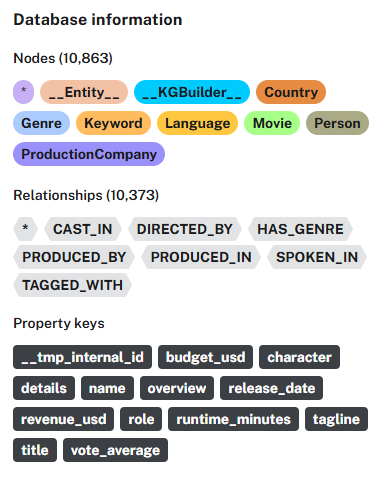

Goto Neo4j sbx and visualise the schema



```
CALL db.schema.visualization()
```



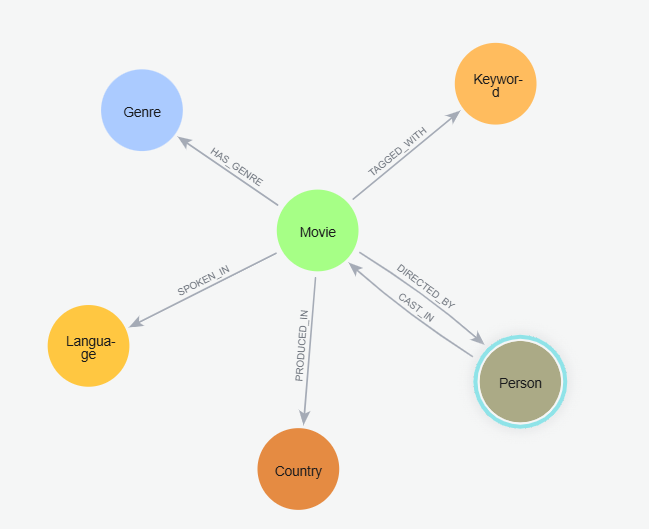

Let's visualise the graph by running this on Neo4j browser



```
MATCH (n)-[r]->(m) RETURN n, r, m
```



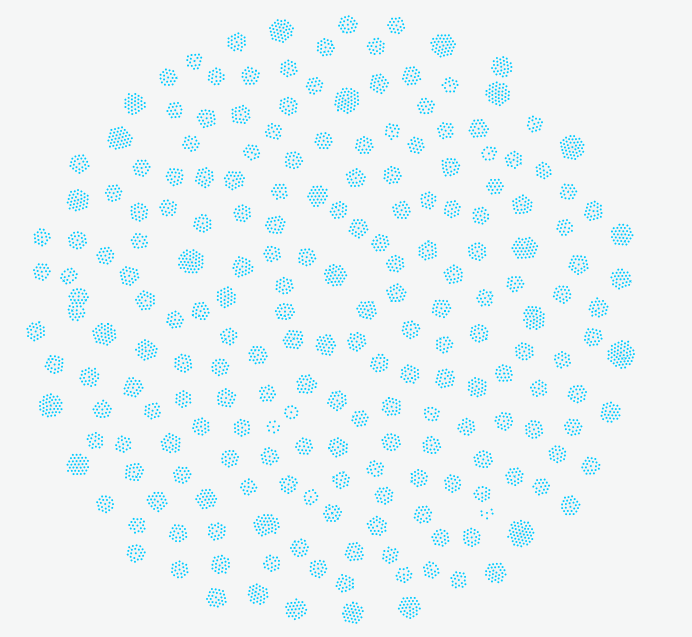

## 8. Entity Resolver

### Cleaning Up Duplicates
Sometimes the AI might find "Christopher Nolan" and "C. Nolan". The resolver looks for exact matches to ensure these are merged into a single person node.

We use exact-match resolution on the most discriminating string property of each node label:
* `Movie` nodes contain `title` as a property
* All other `__Entity__` nodes (Person, Genre, …) share `name`

We run the resolver twice — once on `title`, once on `name` — so that both axes are deduplicated.

**Resolution Logic:**
`Find Nodes` -> `Compare 'name' or 'title'` -> `Merge if Identical` -> `Update Relationships`

In [7]:
from neo4j_graphrag.experimental.components.resolver import SinglePropertyExactMatchResolver

# The SinglePropertyExactMatchResolver performs entity resolution based on the specified 'resolve_property'.
# Here, 'resolver_title' will resolve entities based on their 'title' property.
resolver_title = SinglePropertyExactMatchResolver(driver=driver, resolve_property='title')
res_exactmatch = await resolver_title.run()

# And 'resolver_name' will resolve entities based on their 'name' property.
resolver_name  = SinglePropertyExactMatchResolver(driver=driver, resolve_property='name')
res_exactmatch = await resolver_name.run()

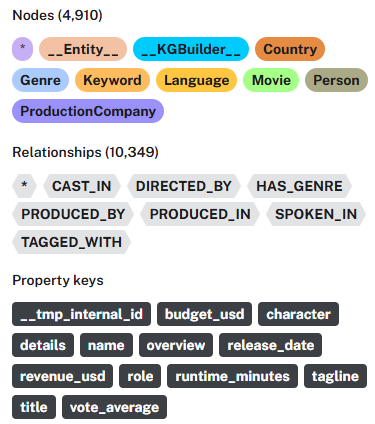

### Check for duplicate nodes after resolution

These queries will help identify if any nodes with the same 'title' (for Movies) or 'name' (for other entities) still exist, indicating if the resolvers successfully merged duplicates or if there were no duplicates to begin with.

In [8]:
import pandas as pd

def run_cypher(query: str, **params) -> pd.DataFrame:
    with driver.session(database=NEO4J_DATABASE) as session:
        res = session.run(query, **params)
        return pd.DataFrame([r.data() for r in res])

In [9]:
print('Checking for duplicate Movie nodes by title:')
duplicate_movies = run_cypher('''
MATCH (m:Movie)
WITH m.title AS movieTitle, count(m) AS count, collect(m) AS movies
WHERE count > 1
RETURN movieTitle, count, [n IN movies | elementId(n)] AS duplicateNodeIds
ORDER BY count DESC, movieTitle
''')
display(duplicate_movies)

if duplicate_movies.empty:
    print('No duplicate Movie nodes found by title.')
else:
    print('Duplicate Movie nodes found by title.')

Checking for duplicate Movie nodes by title:


""


No duplicate Movie nodes found by title.


In [12]:
print('\nChecking for duplicate Person, Genre, ProductionCompany, Country, Language, Keyword nodes by name:')
duplicate_entities_by_name = run_cypher('''
MATCH (n)
WHERE n.name IS NOT NULL AND NOT n:Movie // Exclude Movie nodes as they are checked by title
UNWIND labels(n) AS label
WITH label, n.name AS entityName, count(n) AS count, collect(n) AS entities
WHERE count > 1
RETURN label, entityName, count, [e IN entities | elementId(e)] AS duplicateNodeIds
ORDER BY label, count DESC, entityName
''')
display(duplicate_entities_by_name)

if duplicate_entities_by_name.empty:
    print('No duplicate Person, Genre, ProductionCompany, Country, Language, Keyword nodes found by name.')
else:
    print('Duplicate Person, Genre, ProductionCompany, Country, Language, Keyword nodes found by name.')


Checking for duplicate Person, Genre, ProductionCompany, Country, Language, Keyword nodes by name:


""


No duplicate Person, Genre, ProductionCompany, Country, Language, Keyword nodes found by name.


## 9. Custom Component — Entity Text Embedder

### Advanced Search Readiness
We don't just want to search descriptions; we want to search for people or genres too. This component finds the longest text on every node and creates an embedding for it.

**The Big Picture:**
`Graph Nodes` -> `Select Longest Prop` -> `Embed` -> `Enable Semantic Node Search`

**The below execution takes 30 min to run**

In [ ]:
from neo4j_graphrag.experimental.pipeline import Component, DataModel

class EmbedEntityResult(DataModel):
    updated_count: int


class EntityTextEmbedder(Component):
    """For every `:__Entity__` node, embed its longest string property → e.embedding."""

    def __init__(self, driver, label: str = '__Entity__', embedder=None):
        self.driver = driver
        self.label = label
        self.embedder = embedder

    async def run(self) -> EmbedEntityResult:
        updated = 0
        with self.driver.session(database=NEO4J_DATABASE) as session:
            result = session.run(
                f'MATCH (e:`{self.label}`) RETURN elementId(e) AS id, properties(e) AS props'
            )
            for record in result:
                node_id = record['id']
                props = record['props'] or {}
                str_props = {k: v for k, v in props.items() if isinstance(v, str) and v.strip()}
                if not str_props:
                    continue
                _, text = max(str_props.items(), key=lambda kv: len(kv[1]))
                emb = self.embedder.embed_query(text)
                session.run(
                    'MATCH (e) WHERE elementId(e) = $id SET e.embedding = $embedding',
                    id=node_id, embedding=emb,
                )
                updated += 1
        print(f'Embedded {updated} entity nodes.')
        return EmbedEntityResult(updated_count=updated)


entity_embedder = EntityTextEmbedder(driver=driver, embedder=embedder)
print('EntityTextEmbedder ready ✔')
result = await entity_embedder.run()

EntityTextEmbedder ready ✔


## 10. Assemble & Run the custom Pipeline

### Wiring it All Together
Finally, we connect every component. Think of this like a factory assembly line where the output of one machine is the input for the next.

**Data Highway:**
`Loader` -> `Splitter` -> `Embedder` -> `Schema Builder` -> `Entity Extractor` -> `Writer` -> `Resolvers` -> `Entity Embedder`

In [ ]:
from neo4j_graphrag.experimental.pipeline import Pipeline

pipe = Pipeline()

# 1. Register components
pipe.add_component(loader,              'data_loader')
pipe.add_component(splitter,            'text_splitter')
pipe.add_component(text_chunk_embedder, 'chunk_embedder')
pipe.add_component(schema_builder,      'schema')
pipe.add_component(entity_extractor,    'entity_extractor')
pipe.add_component(eg_writer,           'eg_writer')
pipe.add_component(resolver_title,      'resolver_title')
pipe.add_component(resolver_name,       'resolver_name')
pipe.add_component(entity_embedder,     'entity_embedder')

# 2. Wire data flow
pipe.connect('data_loader',    'text_splitter',    input_config={'page_data':   'data_loader'})
pipe.connect('text_splitter',  'chunk_embedder',   input_config={'text_chunks': 'text_splitter'})
pipe.connect('chunk_embedder', 'entity_extractor', input_config={'chunks':      'chunk_embedder'})
pipe.connect('schema',         'entity_extractor', input_config={'schema':      'schema'})
pipe.connect('entity_extractor','eg_writer',       input_config={'graph':       'entity_extractor'})

# Post-write components — they operate directly on the DB, so no input mapping is needed
pipe.connect('eg_writer', 'resolver_title',  {})
pipe.connect('eg_writer', 'resolver_name',   {})
pipe.connect('eg_writer', 'entity_embedder', {})

In [ ]:
# 3. Inputs that don't come from upstream components
pipe_inputs = {
    'data_loader': {'path': DATA_PATH},
    'schema': {
        'node_types':         node_types,
        'relationship_types': relationship_types,
        'patterns':           patterns,
    },
}


In [ ]:

# 4. Run!
# result = await pipe.run(pipe_inputs)
# print('\nPipeline finished ✔')
# print(result)

## 12. Clean shutdown

In [ ]:
driver.close()
print('Driver closed ✔')

Driver closed ✔
